# Phase 0 — data audit
All pulls are cached in `data/raw/` (URL + sha256 in `manifest.jsonl`). Nothing from 2025 onwards is scored here.

In [1]:
import pandas as pd, matplotlib.pyplot as plt
from windpfn.data import windfor, fuelhh, dayahead_vintage

plt.rcParams.update({"figure.figsize": (10, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3})
BLUE, ORANGE = "#2a78d6", "#eb6834"
w, o = windfor(), fuelhh()

## WINDFOR vintages
4 per day until 2019-09, 8 per day since. Issue times move by +1h in UTC during BST, so there is **no 08:30Z vintage in winter**.

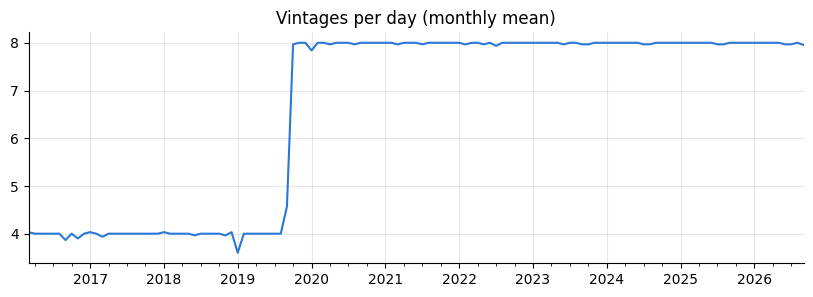

In [2]:
v = w.groupby("publishTime").size()
v.groupby(v.index.floor("D")).size().resample("MS").mean().plot(color=BLUE, xlabel="", title="Vintages per day (monthly mean)");

In [3]:
x = v["2025"].index
pd.crosstab(x.strftime("%H:%M").rename("issue (UTC)"), x.month.rename("month, 2025"))

col_0,1,2,3,4,5,6,7,8,9,10,11,12
row_0,,,,,,,,,,,,
02:30,31,28,29,0,0,0,0,0,0,6,30,31
03:30,0,0,2,30,31,30,31,31,30,25,0,0
04:30,31,28,29,0,0,0,0,0,0,6,30,31
05:30,0,0,2,30,31,30,31,31,30,25,0,0
07:30,31,28,29,0,0,0,0,0,0,6,30,31
08:30,0,0,2,30,31,30,31,31,30,25,0,0
09:30,31,28,29,0,0,0,0,0,0,6,30,31
10:30,0,0,2,30,31,30,30,30,30,25,0,0
11:30,31,28,28,0,0,0,0,0,0,6,29,31


Coverage of delivery day D (24 UTC hours) by the latest vintage at or before D-1 08:30Z:

In [4]:
da = dayahead_vintage(w)
cov = da.groupby(da.index.floor("D")).size()
(cov == 24).groupby(cov.index.year).mean().round(3).to_frame("full_day")

,full_day
startTime,
2016,0.984
2017,0.992
2018,0.992
2019,0.992
2020,0.966
2021,0.989
2022,1.000
2023,1.000
2024,1.000


## Outturn (FUELHH)
Keyed on UTC `startTime`; the API's settlement-date labels are wrong until 2022-07. Clock-change days come out at 46 or 50 periods.

In [5]:
n = o.groupby(o.index.tz_convert("Europe/London").date).size()
n.value_counts()

generation
48    3841
47      25
46      24
50      10
45      10
44       6
1        1
43       1
2        1
Name: count, dtype: int64

## Scope: WINDFOR vs metered outturn (2019–21)
Bias is near zero in the middle deciles and large at high forecasts, consistent with curtailment.

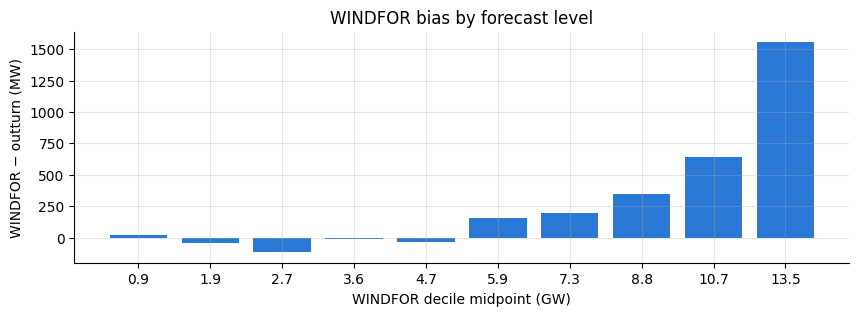

In [6]:
hr = ((o + o.shift(-1, freq="30min")) / 2).rename("y")
j = pd.concat([da.generation.rename("f"), hr], axis=1).dropna().sort_index()["2019":"2021"]
dec = pd.qcut(j.f, 10)
b = (j.f - j.y).groupby(dec, observed=True).mean()
plt.bar(range(10), b, color=BLUE)
plt.xticks(range(10), [f"{i.mid / 1e3:.1f}" for i in b.index])
plt.gca().set(xlabel="WINDFOR decile midpoint (GW)", ylabel="WINDFOR − outturn (MW)", title="WINDFOR bias by forecast level");

## Capacity proxy
The trailing 365-day max of outturn plateaus from 2023 despite new offshore capacity (it is capped by constraints), so it can't be used.

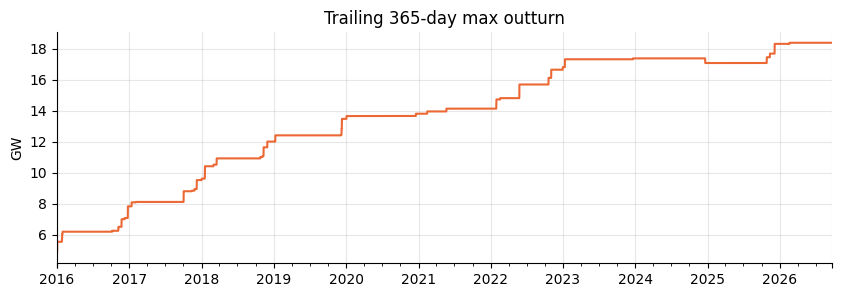

In [7]:
o.resample("1h").mean().rolling("365D").max().div(1e3).plot(color=ORANGE, xlabel="", ylabel="GW", title="Trailing 365-day max outturn");

## NWP
| Source | Verdict |
|---|---|
| Open-Meteo Historical Forecast | stitches early hours of each run, so a near-analysis: **disqualified** |
| Open-Meteo Previous Runs `_day1` | late hours of D come from runs after the cutoff: **leaks** |
| Open-Meteo Single Runs | point-in-time, but no publication timestamps |
| **ECMWF IFS open data** (GCS/AWS mirrors) | point-in-time, with publication time from each file's `Last-Modified`: **used** (`windpfn.nwp`) |